# GHP Construction with Duration Matching

In [7]:
import numpy as np
import pandas as pd
import kit as erk 


In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
erk.bond_cash_flows(3, 100, 0.03, 2)

1      1.5
2      1.5
3      1.5
4      1.5
5      1.5
6    101.5
dtype: float64

In [5]:
erk.bond_price(20, 1000, 0.05, 2, 0.05)

1000.0000000000023

In [6]:
# How can the price of the bond change based on the interest rate

In [9]:
rates = np.linspace(.01, .10, num=20)
rates 

array([0.01      , 0.01473684, 0.01947368, 0.02421053, 0.02894737,
       0.03368421, 0.03842105, 0.04315789, 0.04789474, 0.05263158,
       0.05736842, 0.06210526, 0.06684211, 0.07157895, 0.07631579,
       0.08105263, 0.08578947, 0.09052632, 0.09526316, 0.1       ])

In [14]:
prices =[erk.bond_price(10, 1000, .05, 2, rate) for rate in rates]
prices

[1379.7483829333992,
 1326.7629283179222,
 1276.1632981372743,
 1227.833537616068,
 1181.6636507727876,
 1137.5492793724407,
 1095.3913999300185,
 1055.0960377089511,
 1016.5739967228162,
 979.7406048086303,
 944.5154728963505,
 910.8222676519945,
 878.5884967212596,
 847.74530584692,
 818.2272871767957,
 789.9722981198867,
 762.9212901465673,
 737.0181469646424,
 712.209531536784,
 688.4447414365]

<Axes: title={'center': 'Change in price of 10 year bonds with difference interest'}>

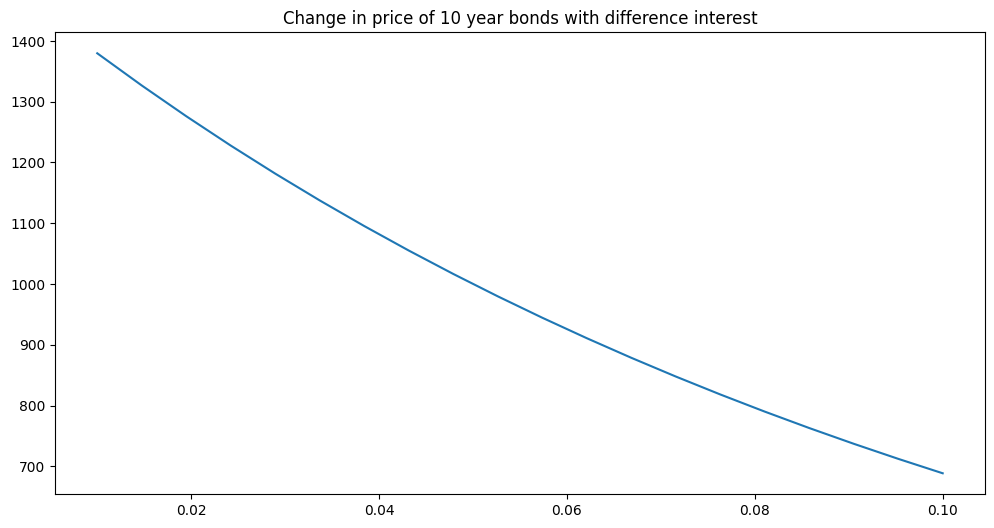

In [18]:
pd.DataFrame(data=prices, index=rates).plot(title="Change in price of 10 year bonds with difference interest", legend=False, figsize=(12, 6))

In [ ]:
# Construct combination of bond that resilience with interest rate

In [20]:
cf = erk.bond_cash_flows(3, 1000, .06, 2)
cf

1      30.0
2      30.0
3      30.0
4      30.0
5      30.0
6    1030.0
dtype: float64

In [22]:
discounts = erk.discount(cf.index, .06/2)
discounts

Index([ 0.970873786407767, 0.9425959091337544, 0.9151416593531595,
       0.8884870479156888, 0.8626087843841639, 0.8374842566836542],
      dtype='float64')

In [27]:
dcf = discounts * cf
weights = dcf/dcf.sum()

In [30]:
#Maucaulay Duration 
(cf.index*weights).sum()

5.579707187194534

In [31]:
erk.macaulay_duration(erk.bond_cash_flows(3, 1000, .06, 2), .06/2)

5.579707187194534

# Duration Matching

In [32]:
liabilities = pd.Series(data=[10000, 10000], index=[10, 12])
erk.macaulay_duration(liabilities, .04)

10.960799385088393

In [33]:
md_10 = erk.macaulay_duration(erk.bond_cash_flows(10, 1000, .05, 1), .04)
md_20 = erk.macaulay_duration(erk.bond_cash_flows(20, 1000, .05, 1), .04)

In [34]:
md_10, md_20

(8.190898824083233, 13.544718122145921)

In [39]:
short_bond = erk.bond_cash_flows(10, 1000, .05, 1)
long_bond = erk.bond_cash_flows(20, 1000, .05, 1)
w_s = erk.match_duration(liabilities, short_bond, long_bond, .04)
w_s

0.48263092069478974

In [51]:
p_short = erk.bond_price(10, 1000, .05, 1, .04)
p_long = erk.bond_price(20, 1000, .05, 1, .04)
a_0 = 13000

In [58]:
p_short, p_long

(1081.10895779355, 1135.9032634496762)

In [59]:
p_flows = pd.concat([a_0*w_s*short_bond/p_short, a_0*(1-w_s)*long_bond/p_long])
erk.macaulay_duration(p_flows, 0.04)
p_flows

1      290.174359
2      290.174359
3      290.174359
4      290.174359
5      290.174359
6      290.174359
7      290.174359
8      290.174359
9      290.174359
10    6093.661532
1      296.055054
2      296.055054
3      296.055054
4      296.055054
5      296.055054
6      296.055054
7      296.055054
8      296.055054
9      296.055054
10     296.055054
11     296.055054
12     296.055054
13     296.055054
14     296.055054
15     296.055054
16     296.055054
17     296.055054
18     296.055054
19     296.055054
20    6217.156126
dtype: float64

In [53]:
cfr = erk.funding_ratio(p_flows, liabilities, .04)
cfr

0.9998760012192476

In [56]:
rates = np.linspace(0, .1, 20)

lb_assets = a_0*long_bond/p_long
sb_assets = a_0*short_bond/p_short

fr_change = pd.DataFrame( {
    "Long Bond": [erk.funding_ratio(lb_assets, liabilities, r) for r in rates],
    "Short Bond": [erk.funding_ratio(sb_assets, liabilities, r) for r in rates],
    "Duration Matched": [erk.funding_ratio(p_flows, liabilities, r) for r in rates]
})

<Axes: title={'center': 'Funding Ratio with change in interest rate'}>

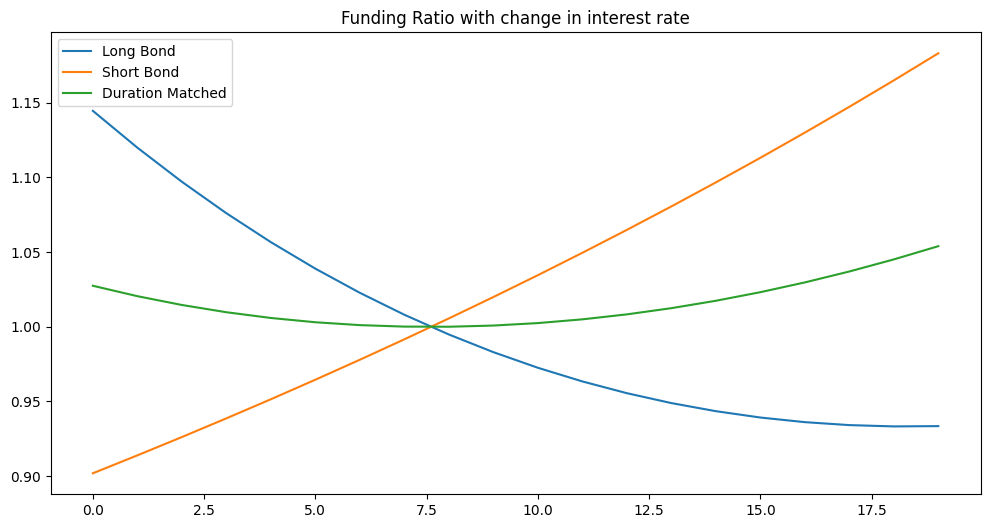

In [57]:
fr_change.plot(title="Funding Ratio with change in interest rate", figsize=(12, 6))